Observation space:  Dict('aircraft': Box([-470. -470. -470. -180.  -90.    0.], [470. 470. 470. 180.  90. 360.], (6,), float32), 'missile': Box([-15000. -15000. -15000.  -1870.  -1870.  -1870.], [15000. 15000. 15000.  1870.  1870.  1870.], (6,), float32))
Action space Box([-1. -1. -1.  0.], 1.0, (4,), float32)
Cumulative reward = 420.5052795410156
Distance b/w missile and aircraft : 5.387325286865234
Number of steps = 1201


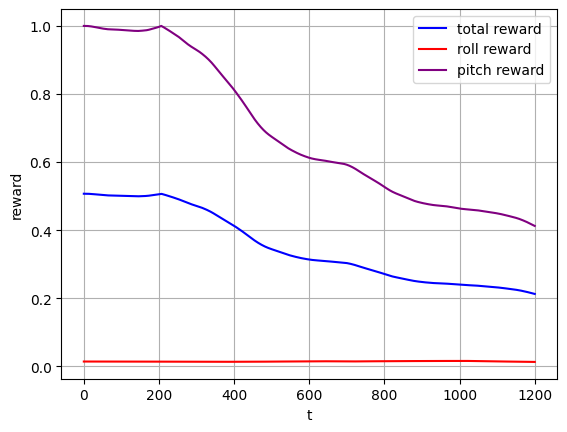

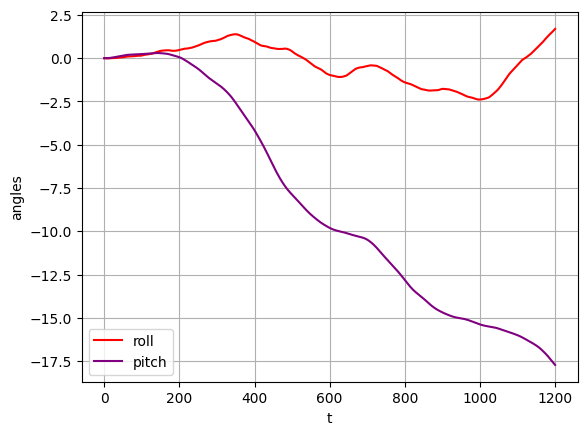

In [ ]:
import gymnasium as gym
import envs
import matplotlib.pyplot as plt

env = gym.make("AirMissileEnv-SteepTurn-v0", render_mode="human")
print("Observation space: ", env.observation_space)
print("Action space", env.action_space)

obs, info = env.reset()

done = False
cumulative_reward = 0
R = []
R_roll = []
R_pitch = []
pitch = []
roll = []

while not done:
    a = env.action_space.sample()
    obs, r, term, trunc, info = env.step(a)
    cumulative_reward += r
    
    roll.append(obs['aircraft'][3])
    pitch.append(obs['aircraft'][4])

    R.append(r)
    R_roll.append(info["Roll reward"])
    R_pitch.append(info["Pitch reward"])
    done = term or trunc
    
print(f"Cumulative reward = {cumulative_reward}")
print(f"Distance b/w missile and aircraft : {info["Distance"]}")
print(f"Number of steps = {info["Steps"]}")


plt.xlabel("t")
plt.ylabel("reward")
plt.plot(R, c='b', label="total reward")
plt.plot(R_roll, c='r', label="roll reward")
plt.plot(R_pitch, c='purple', label="pitch reward")
plt.grid()
plt.legend()
plt.show()

plt.xlabel("t")
plt.ylabel("angles")
plt.plot(roll, c='r', label="roll")
plt.plot(pitch, c='purple', label="pitch")
plt.grid()
plt.legend()
plt.show()


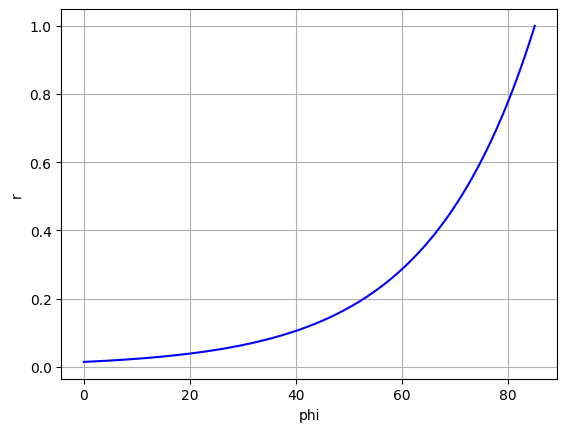

In [7]:
import numpy as np

x = np.linspace(0, 85, 200)
y = np.exp(- np.abs(x - 85) / 20)

plt.xlabel("phi")
plt.ylabel("r")
plt.plot(x, y ,c='b')
plt.grid()
plt.show()